In [272]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    multilabel_confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import joblib


In [273]:
# labelled_emails_df = pd.read_csv('../data/04_encoded_labelled_emails.csv')
# labelled_emails_df.sample(10, random_state=12)

In [274]:
Y_train = np.load('../model_data/Y_train.npy')
Y_test = np.load('../model_data/Y_test.npy')

print('Y_train: ', Y_train)
print('Y_test: ', Y_test)
print('shape: ', Y_train.shape, Y_test.shape)

X_train = np.load("../model_data/X_train_bert.npy")
X_test = np.load("../model_data/X_test_bert.npy")

print('X_train: ', X_train)
print('X_test: ', X_test)
print('shape: ', X_train.shape, X_test.shape)

Y_train:  [[0 0 0 1]
 [0 0 0 1]
 [0 1 0 0]
 ...
 [0 0 1 0]
 [1 0 0 0]
 [0 1 0 0]]
Y_test:  [[0 0 1 0]
 [0 1 0 0]
 [0 1 0 0]
 ...
 [0 1 0 0]
 [0 0 0 1]
 [1 0 0 0]]
shape:  (1910, 4) (478, 4)
X_train:  [[-0.42312354 -0.54868555 -0.9643042  ... -0.83245724 -0.47842208
   0.39699167]
 [-0.57316715 -0.5088102  -0.9850985  ... -0.9398462  -0.6190099
   0.5867044 ]
 [-0.74162996 -0.547777   -0.9917878  ... -0.9471306  -0.71309376
   0.6183656 ]
 ...
 [-0.66844153 -0.53841984 -0.98510987 ... -0.9122262  -0.6085401
   0.66095567]
 [-0.5810163  -0.5780096  -0.9945758  ... -0.93074936 -0.59250724
   0.46010888]
 [-0.5250289  -0.4235095  -0.7941735  ... -0.6300716  -0.5897973
   0.7063313 ]]
X_test:  [[-0.7456036  -0.44178432 -0.93770844 ... -0.6760092  -0.699894
   0.7909855 ]
 [-0.22628589 -0.67924935 -0.9985358  ... -0.97362983 -0.58610976
   0.00793173]
 [-0.4620166  -0.5690267  -0.9506907  ... -0.8115123  -0.6664765
   0.5361389 ]
 ...
 [-0.70236105 -0.6138162  -0.9966875  ... -0.9764868  -0.

## Train a Logistic Regression classifier

In [275]:
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000))
log_reg.fit(X_train, Y_train)

y_pred_probs_log_reg = log_reg.predict_proba(X_test)

# Convert to shape (n_samples, n_classes)
# y_pred_probs_log_reg_arr = np.stack([p[:, 1] for p in y_pred_probs_log_reg], axis=1)

threshold_log_reg = 0.2
y_pred_log_reg_custom = (y_pred_probs_log_reg >= threshold_log_reg).astype(int)
# y_pred_log_reg = log_reg.predict(X_test)
# y_pred_log_reg

## Evaluate the Logistic Regression classifier

In [276]:
# conf_matrix_log_reg = confusion_matrix(Y_test.argmax(axis=1), y_pred_log_reg.argmax(axis=1))
# sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Greens',
#             xticklabels=['D', 'I', 'S', 'C'], yticklabels=['D', 'I', 'S', 'C'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix for Logistic Regression')
# plt.show()

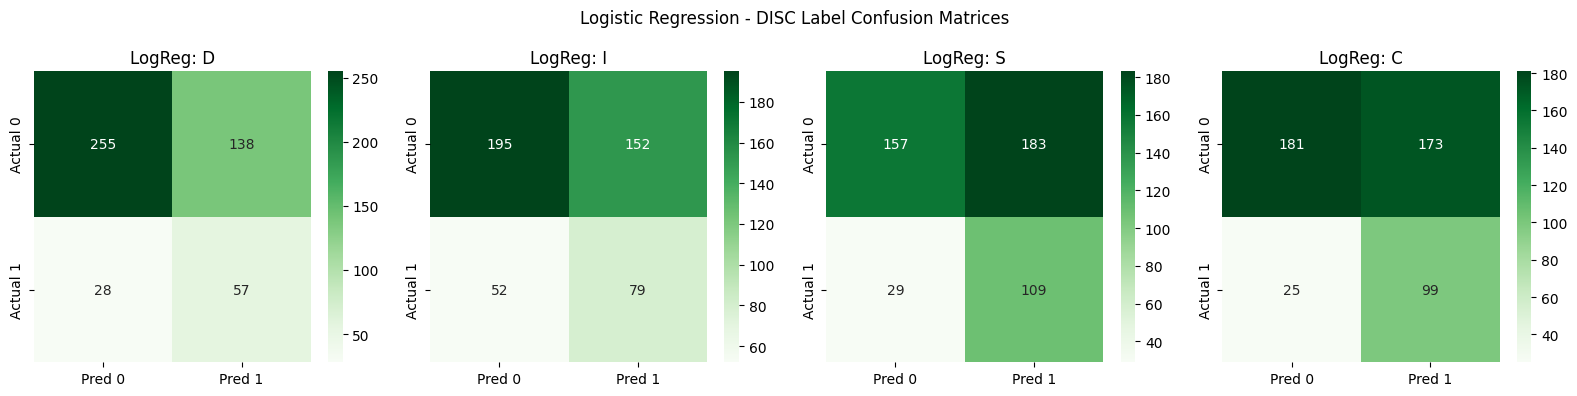

<Figure size 640x480 with 0 Axes>

In [277]:
labels = ['D', 'I', 'S', 'C']
conf_matrix_log_reg = multilabel_confusion_matrix(Y_test, y_pred_log_reg_custom)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, label in enumerate(labels):
    sns.heatmap(conf_matrix_log_reg[i], annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=axes[i])
    axes[i].set_title(f"LogReg: {label}")

plt.suptitle("Logistic Regression - DISC Label Confusion Matrices")
plt.tight_layout()
plt.show()

plt.savefig('../figures/06_log_reg_bootstrap_0.2_confusion_matrices.png')

In [278]:
print("Logistic Regression with threshold of 0.2: ", classification_report(Y_test, y_pred_log_reg_custom, target_names=labels))

Logistic Regression with threshold of 0.2:                precision    recall  f1-score   support

           D       0.29      0.67      0.41        85
           I       0.34      0.60      0.44       131
           S       0.37      0.79      0.51       138
           C       0.36      0.80      0.50       124

   micro avg       0.35      0.72      0.47       478
   macro avg       0.34      0.72      0.46       478
weighted avg       0.35      0.72      0.47       478
 samples avg       0.37      0.72      0.48       478



In [279]:
joblib.dump(log_reg, "../models/log_reg_bootstrap_thresh_0.2.pkl")

['../models/log_reg_bootstrap_thresh_0.2.pkl']

## Train an MLP

In [280]:
mlp = Sequential()
mlp.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
mlp.add(Dropout(0.1))
mlp.add(Dense(336, activation='relu'))
mlp.add(Dropout(0.1))
mlp.add(Dense(4, activation='sigmoid'))


/Users/pkchoy/Portfo/disc-predictor-for-business/.business-disc/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [281]:
mlp.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [282]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = mlp.fit(X_train, Y_train, epochs=30, batch_size=32, callbacks=early_stop, validation_split=0.2, verbose=1)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2537 - loss: 0.6028 - val_accuracy: 0.2827 - val_loss: 0.5593
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2737 - loss: 0.5587 - val_accuracy: 0.3403 - val_loss: 0.5501
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3258 - loss: 0.5537 - val_accuracy: 0.2984 - val_loss: 0.5533
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2994 - loss: 0.5545 - val_accuracy: 0.3298 - val_loss: 0.5482
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3422 - loss: 0.5483 - val_accuracy: 0.3586 - val_loss: 0.5452
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3321 - loss: 0.5482 - val_accuracy: 0.3246 - val_loss: 0.5465
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3654 - loss: 0.5455 - val_accuracy: 0.3770 - val_loss: 0.5470
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3619 - loss: 0.5419 - val_accuracy: 0.4241 - val_loss:

In [283]:
loss, accuracy = mlp.evaluate(X_test, Y_test)
print('Test Loss: ', loss)
print('Test Accuracy: ', accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.3668 - loss: 0.5410
Test Loss:  0.543823778629303
Test Accuracy:  0.37029287219047546


In [284]:
threshold_mlp = 0.2
y_pred_probs_mlp = mlp.predict(X_test)
# y_pred_mlp = np.where(y_pred_probs_mlp >= threshold, 1, 0)
y_pred_mlp = (y_pred_probs_mlp >= threshold_mlp).astype(int)
# confusion_matrix_mlp = confusion_matrix(Y_test.argmax(axis=1, y_pred_mlp.argmax(axis=1))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [285]:
print("MLP with threshold of 0.2: ", classification_report(Y_test, y_pred_mlp, target_names=['D', 'I', 'S', 'C']))

MLP with threshold of 0.2:                precision    recall  f1-score   support

           D       0.27      0.74      0.39        85
           I       0.31      0.61      0.41       131
           S       0.30      0.96      0.46       138
           C       0.30      0.85      0.45       124

   micro avg       0.30      0.80      0.43       478
   macro avg       0.30      0.79      0.43       478
weighted avg       0.30      0.80      0.43       478
 samples avg       0.31      0.80      0.44       478



In [286]:
print(Y_train.sum(axis=0))  # Count of D, I, S, C in training data

[418 451 536 505]


In [287]:
# conf_matrix_mlp = confusion_matrix(Y_test.argmax(axis=1), y_pred_mlp.argmax(axis=1))
# sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['D', 'I', 'S', 'C'], yticklabels=['D', 'I', 'S', 'C'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix for MLP')
# plt.show()

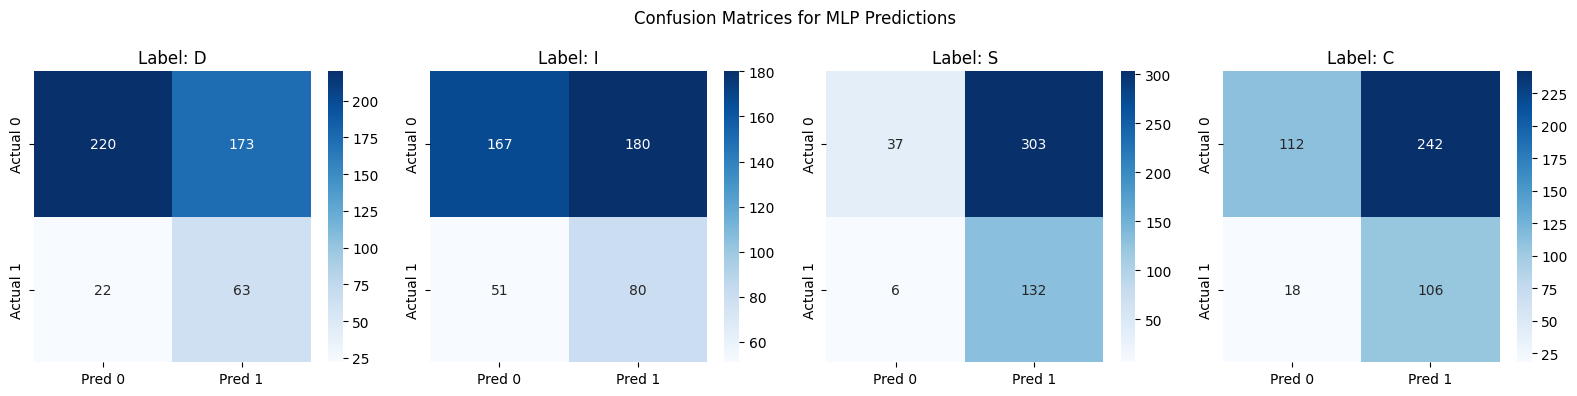

<Figure size 640x480 with 0 Axes>

In [288]:
conf_matrix_mlp = multilabel_confusion_matrix(Y_test, y_pred_mlp)

# Plot each label's confusion matrix
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, label in enumerate(labels):
    sns.heatmap(conf_matrix_mlp[i], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=axes[i])
    axes[i].set_title(f"Label: {label}")

plt.suptitle("Confusion Matrices for MLP Predictions")
plt.tight_layout()
plt.show()

plt.savefig('../figures/06_mlp_bootstrap_0.2_confusion_matrices.png')


In [289]:
mlp.save('../models/mlp_bootstrap_thresh_0.2.h5')